In [1]:
import pandas as pd

# 1. BOTZ ETF verisini yükle ve temizle
botz = pd.read_csv("botz_monthly_price.csv")
# 'BOTZ' gibi metinleri NaN yapar, sonra o satırları sileriz
botz["botz_price"] = pd.to_numeric(botz["botz_price"], errors='coerce')
botz = botz.dropna(subset=["botz_price", "month_year"])
botz.rename(columns={"month_year": "month"}, inplace=True)

# 2. Yapay Zeka Makale verisini yükle
papers = pd.read_csv("ai_monthly_papers.csv")

# 3. İki veri setini 'month' (ay) bazında birleştir
df = pd.merge(botz, papers, on="month", how="inner").sort_values("month")

print("Veri Seti Hazır! İlk 5 Satır:")
print(df.head())

Veri Seti Hazır! İlk 5 Satır:
     month  botz_price  paper_count
0  2016-09   14.699145          125
1  2016-10   14.420717          160
2  2016-11   14.478322          183
3  2016-12   14.410190          156
4  2017-01   15.673486          145


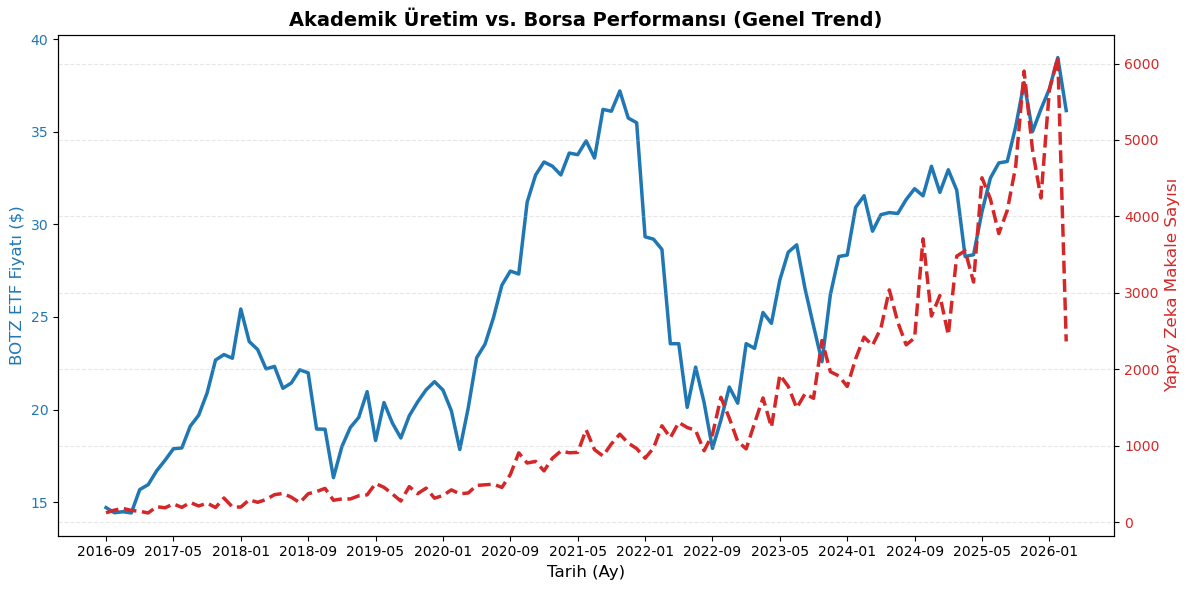

In [2]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

# Sol Eksen: BOTZ ETF Fiyatı (Mavi)
color1 = 'tab:blue'
ax1.set_xlabel('Tarih (Ay)', fontsize=12)
ax1.set_ylabel('BOTZ ETF Fiyatı ($)', color=color1, fontsize=12)
ax1.plot(df['month'], df['botz_price'], color=color1, linewidth=2.5, label="BOTZ Fiyatı")
ax1.tick_params(axis='y', labelcolor=color1)

# Sağ Eksen: Makale Sayısı (Kırmızı)
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Yapay Zeka Makale Sayısı', color=color2, fontsize=12)
ax2.plot(df['month'], df['paper_count'], color=color2, linewidth=2.5, linestyle='--', label="Makale Sayısı")
ax2.tick_params(axis='y', labelcolor=color2)

# X Eksenindeki tarihlerin üst üste binmemesi için aralıklı gösterim
plt.xticks(df['month'][::8], rotation=45) 

plt.title("Akademik Üretim vs. Borsa Performansı (Genel Trend)", fontsize=14, fontweight='bold')
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [3]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series, name):
    p_value = adfuller(series.dropna())[1]
    is_stationary = p_value < 0.05
    durum = "Durağan" if is_stationary else "Durağan DEĞİL"
    print(f"[{name}] ADF p-değeri: {p_value:.4f} -> {durum}")

print("--- Orijinal Veriler (Trend İçerenler) ---")
check_stationarity(df["botz_price"], "BOTZ Fiyatı")
check_stationarity(df["paper_count"], "Makale Sayısı")

# Verileri durağanlaştırmak için 2. dereceden fark (diff) alıyoruz
df_diff = df[['botz_price', 'paper_count']].diff().diff().dropna()

print("\n--- 2. Dereceden Fark Alındıktan Sonra ---")
check_stationarity(df_diff["botz_price"], "BOTZ Fiyatı (İvme)")
check_stationarity(df_diff["paper_count"], "Makale Sayısı (İvme)")

--- Orijinal Veriler (Trend İçerenler) ---
[BOTZ Fiyatı] ADF p-değeri: 0.5473 -> Durağan DEĞİL
[Makale Sayısı] ADF p-değeri: 1.0000 -> Durağan DEĞİL

--- 2. Dereceden Fark Alındıktan Sonra ---
[BOTZ Fiyatı (İvme)] ADF p-değeri: 0.0000 -> Durağan
[Makale Sayısı (İvme)] ADF p-değeri: 0.0000 -> Durağan


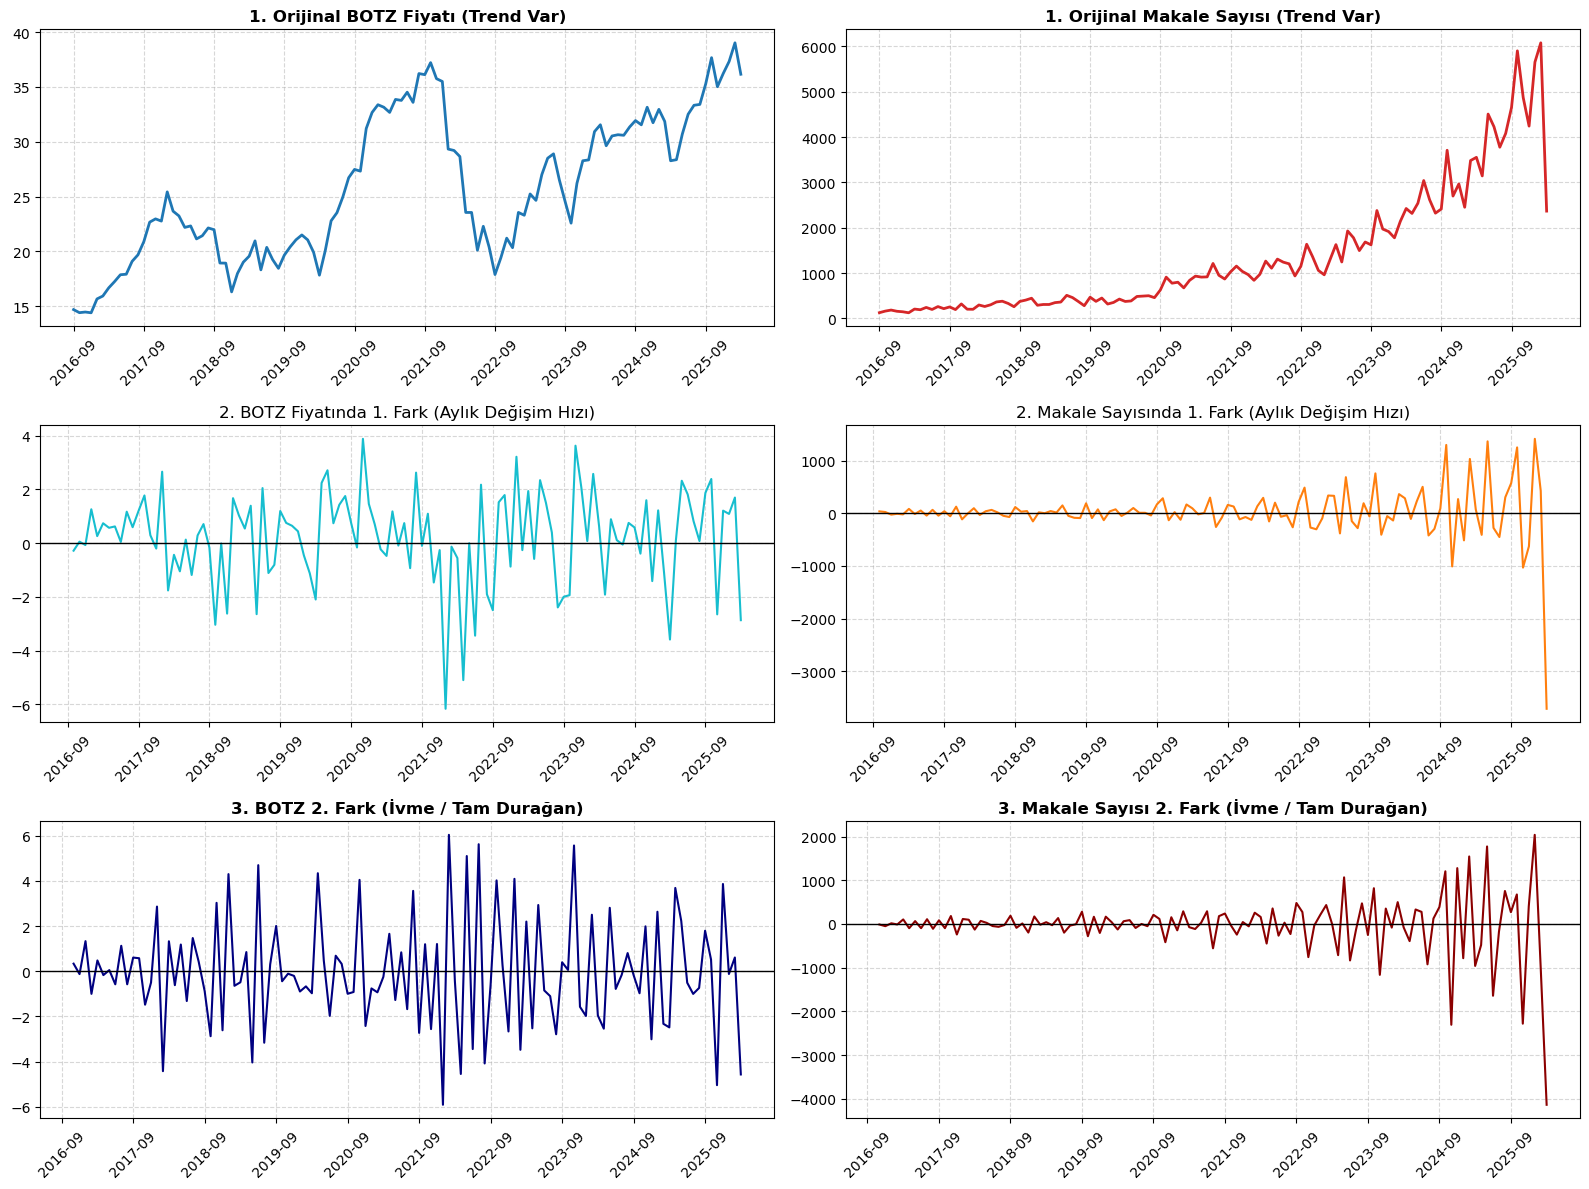

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Verileri Yükle ve Temizle
botz = pd.read_csv("botz_monthly_price.csv")
botz["botz_price"] = pd.to_numeric(botz["botz_price"], errors='coerce')
botz = botz.dropna(subset=["botz_price", "month_year"])
botz.rename(columns={"month_year": "month"}, inplace=True)
papers = pd.read_csv("ai_monthly_papers.csv")
df = pd.merge(botz, papers, on="month", how="inner").sort_values("month")

# İndeksi tarih olarak ayarla (X ekseni etiketleri için kolaylık sağlar)
df.set_index('month', inplace=True)

# 2. Fark (Değişim) Hesaplamaları
# 1. Fark: Her ayın bir önceki aydan farkı (Hız)
df_diff1 = df.diff()          
# 2. Fark: Değişim hızının bir önceki aydan farkı (İvme)
df_diff2 = df.diff().diff()   

# 3. Görselleştirme (3 Satır x 2 Sütunluk Panel)
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# --- 1. SATIR: ORİJİNAL VERİLER (Sürekli Artan Trend) ---
axes[0, 0].plot(df.index, df['botz_price'], color='tab:blue', linewidth=2)
axes[0, 0].set_title('1. Orijinal BOTZ Fiyatı (Trend Var)', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(df.index[::12]) # Sadece yılda bir kez tarihi göster
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].plot(df.index, df['paper_count'], color='tab:red', linewidth=2)
axes[0, 1].set_title('1. Orijinal Makale Sayısı (Trend Var)', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(df.index[::12])
axes[0, 1].tick_params(axis='x', rotation=45)

# --- 2. SATIR: 1. DERECEDEN FARK (Değişim Hızı) ---
axes[1, 0].plot(df_diff1.index, df_diff1['botz_price'], color='tab:cyan', linewidth=1.5)
axes[1, 0].set_title('2. BOTZ Fiyatında 1. Fark (Aylık Değişim Hızı)', fontsize=12)
axes[1, 0].axhline(0, color='black', linestyle='-', linewidth=1) # Sıfır Çizgisi
axes[1, 0].set_xticks(df_diff1.index[::12])
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].plot(df_diff1.index, df_diff1['paper_count'], color='tab:orange', linewidth=1.5)
axes[1, 1].set_title('2. Makale Sayısında 1. Fark (Aylık Değişim Hızı)', fontsize=12)
axes[1, 1].axhline(0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_xticks(df_diff1.index[::12])
axes[1, 1].tick_params(axis='x', rotation=45)

# --- 3. SATIR: 2. DERECEDEN FARK (İvme - Durağanlaştırılmış Veri) ---
axes[2, 0].plot(df_diff2.index, df_diff2['botz_price'], color='navy', linewidth=1.5)
axes[2, 0].set_title('3. BOTZ 2. Fark (İvme / Tam Durağan)', fontsize=12, fontweight='bold')
axes[2, 0].axhline(0, color='black', linestyle='-', linewidth=1)
axes[2, 0].set_xticks(df_diff2.index[::12])
axes[2, 0].tick_params(axis='x', rotation=45)

axes[2, 1].plot(df_diff2.index, df_diff2['paper_count'], color='darkred', linewidth=1.5)
axes[2, 1].set_title('3. Makale Sayısı 2. Fark (İvme / Tam Durağan)', fontsize=12, fontweight='bold')
axes[2, 1].axhline(0, color='black', linestyle='-', linewidth=1)
axes[2, 1].set_xticks(df_diff2.index[::12])
axes[2, 1].tick_params(axis='x', rotation=45)

# Ortak Tasarım Ayarları
for ax in axes.flatten():
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [4]:
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore') # Uyarı mesajlarını gizlemek için

max_lag = 6 # 6 aylık bir gecikmeye kadar bakacağız

print("HİPOTEZ 1: Makale Sayısındaki Artış -> Borsayı (BOTZ) Tetikler mi?")
print("-" * 65)
gc_papers_lead = grangercausalitytests(df_diff[['botz_price', 'paper_count']], maxlag=max_lag, verbose=False)
for lag in range(1, max_lag + 1):
    p_val = gc_papers_lead[lag][0]['ssr_ftest'][1]
    sonuc = "ANLAMLI" if p_val < 0.05 else "Anlamlı Değil"
    print(f"Gecikme {lag} Ay | p-değeri = {p_val:.4f} | Sonuç: {sonuc}")


print("\nHİPOTEZ 2 (TERS): Borsadaki Artış (BOTZ) -> Makale Sayısını Tetikler mi?")
print("-" * 65)
gc_market_lead = grangercausalitytests(df_diff[['paper_count', 'botz_price']], maxlag=max_lag, verbose=False)
for lag in range(1, max_lag + 1):
    p_val = gc_market_lead[lag][0]['ssr_ftest'][1]
    sonuc = "*** ANLAMLI ***" if p_val < 0.05 else "Anlamlı Değil"
    print(f"Gecikme {lag} Ay | p-değeri = {p_val:.4f} | Sonuç: {sonuc}")

HİPOTEZ 1: Makale Sayısındaki Artış -> Borsayı (BOTZ) Tetikler mi?
-----------------------------------------------------------------
Gecikme 1 Ay | p-değeri = 0.8356 | Sonuç: Anlamlı Değil
Gecikme 2 Ay | p-değeri = 0.7076 | Sonuç: Anlamlı Değil
Gecikme 3 Ay | p-değeri = 0.4974 | Sonuç: Anlamlı Değil
Gecikme 4 Ay | p-değeri = 0.4202 | Sonuç: Anlamlı Değil
Gecikme 5 Ay | p-değeri = 0.1308 | Sonuç: Anlamlı Değil
Gecikme 6 Ay | p-değeri = 0.2579 | Sonuç: Anlamlı Değil

HİPOTEZ 2 (TERS): Borsadaki Artış (BOTZ) -> Makale Sayısını Tetikler mi?
-----------------------------------------------------------------
Gecikme 1 Ay | p-değeri = 0.4412 | Sonuç: Anlamlı Değil
Gecikme 2 Ay | p-değeri = 0.3265 | Sonuç: Anlamlı Değil
Gecikme 3 Ay | p-değeri = 0.0102 | Sonuç: *** ANLAMLI ***
Gecikme 4 Ay | p-değeri = 0.0091 | Sonuç: *** ANLAMLI ***
Gecikme 5 Ay | p-değeri = 0.0058 | Sonuç: *** ANLAMLI ***
Gecikme 6 Ay | p-değeri = 0.0255 | Sonuç: *** ANLAMLI ***
